# Task 1

Points: 20

You will be working with RGBNet: a network that accepts pixel position as input and outputs a triplet with R, G, B channels of that pixels.
RGBNet is trained on a fixed image. Your tasks are:

1. (14 points) Fill gaps in the code, which creates embeddings in 2 ways:
    - Learned embedding of size 64 (7 points)
    - Positional embedding of size 64 (7 points)


Please note that your code should train within 1 minute and report training loss below 15 for each case.
2. (6 points) Visualize output of the network for each encoding. Does it resemble the input image?

In [2]:
import math
import urllib
from typing import Literal

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

IMG_URL = "https://i.natgeofe.com/k/8fa25ea4-6409-47fb-b3cc-4af8e0dc9616/red-eyed-tree-frog-on-leaves-3-2.jpg"

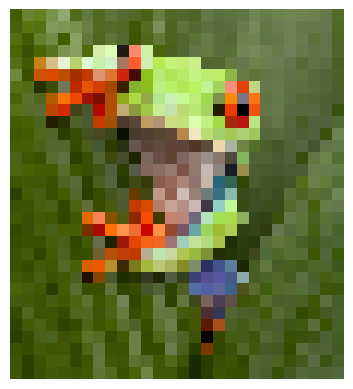

In [3]:
url_response = urllib.request.urlopen(IMG_URL)
img = cv2.imdecode(np.array(bytearray(url_response.read()), dtype=np.uint8), -1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (0,0), fx=0.01, fy=0.01) 
im_w, im_h = img.shape[0], img.shape[1]

plt.imshow(img)
plt.axis('off')
plt.show()

In [40]:
class NaiveEncoding(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.linear = nn.Linear(2, 64)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x.float())


class LearnedEncoding(nn.Module):
    def __init__(self) -> None:
        super().__init__()  # Add this line!

        self.embed_x = nn.Embedding(im_w, 32)
        self.embed_y = nn.Embedding(im_h, 32)
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Your code goes here. Output dim of embedding should be 64 
        x_coord = x[:, 0]
        y_coord = x[:, 1]
        x_embed = self.embed_x(x_coord)
        y_emded = self.embed_y(y_coord)

        return torch.cat([x_embed, y_emded], dim=-1)


class PositionalEncoding(nn.Module):    
    def __init__(self) -> None:
        super().__init__()
        # No learnable parameters - it's a fixed mathematical encoding
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        device = x.device
        
        # x is shape (batch, 2) with (x_coord, y_coord)
        x_coord = x[:, 0]  # shape (batch,)
        y_coord = x[:, 1]  # shape (batch,)
        
        # Create positional encodings for each coordinate (32 dims each)
        x_encoding = torch.zeros(batch_size, 32, device=device)
        y_encoding = torch.zeros(batch_size, 32, device=device)
        
        # Compute sinusoidal encodings
        for i in range(16):
            # Even indices: sin
            x_encoding[:, 2*i] = torch.sin(x_coord / (10000 ** (2*i / 32)))
            y_encoding[:, 2*i] = torch.sin(y_coord / (10000 ** (2*i / 32)))
            # Odd indices: cos
            x_encoding[:, 2*i + 1] = torch.cos(x_coord / (10000 ** (2*i / 32)))
            y_encoding[:, 2*i + 1] = torch.cos(y_coord / (10000 ** (2*i / 32)))
        
        # Concatenate to get 64 dimensions
        return torch.cat([x_encoding, y_encoding], dim=-1)


# Define the network
class RGBNet(nn.Module):
    def __init__(self, encoding_type: Literal["naive", "learned", "positional"]) -> None:
        super().__init__()
        if encoding_type == "naive":
            self.encoding = NaiveEncoding()
        elif encoding_type == "learned":
            self.encoding = LearnedEncoding() 
        elif encoding_type == "positional":
            self.encoding = PositionalEncoding()
        else:
            raise ValueError("Wrong encoding type!")
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 3)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.encoding(x)
        x = F.softplus(self.fc1(x))
        x = F.softplus(self.fc2(x))
        x = self.fc3(x)
        return x


In [ ]:
def train(used_embedding: Literal["naive", "learned", "positional"]) -> torch.nn.Module:
    # Instantiate the model and set it to the GPU (if available)
    model = RGBNet(encoding_type=used_embedding)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Define the loss function and optimizer
    criterion = nn.MSELoss(reduction="mean")
    optimizer = optim.AdamW(model.parameters(), lr=0.01)

    # Define the number of epochs and batch size
    num_epochs = 300
    batch_size = 32

    X, y = torch.cartesian_prod(torch.tensor(range(im_w)), torch.tensor(range(im_h))).to(device), torch.flatten(torch.tensor(img, dtype=torch.float32), start_dim=0, end_dim=1).to(device)

    model = model.train()

    # Train the model
    for epoch in range(num_epochs):
        total_loss = 0
        perm = torch.randperm(X.size(0))
        X, y = X[perm,:], y[perm, :]
        for i in range(0, X.shape[0], batch_size):
            # Get the current batch
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/X.size(0)}')
    return model

In [67]:
def visualize_model_output(model: RGBNet) -> None:
    # Your code goes here. Visualize the predicted image from pixels
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    pixels = torch.cartesian_prod(torch.tensor(range(im_w)), torch.tensor(range(im_h))).to(device)

    model.eval()
    with torch.no_grad():
        colors = model(pixels)
    
    colors = colors.view(im_w, im_h, 3).cpu().int().numpy()

    plt.imshow(colors)
    plt.axis('off')
    plt.show()
    

Epoch [1/300], Loss: 142.93328351139473
Epoch [2/300], Loss: 99.95820568453881
Epoch [3/300], Loss: 81.26916278891849
Epoch [4/300], Loss: 69.43683255103326
Epoch [5/300], Loss: 73.48435854582193
Epoch [6/300], Loss: 67.35187105099726
Epoch [7/300], Loss: 61.88061811737201
Epoch [8/300], Loss: 56.5208489202684
Epoch [9/300], Loss: 65.23209855743268
Epoch [10/300], Loss: 54.342882534325945
Epoch [11/300], Loss: 54.807970108524444
Epoch [12/300], Loss: 51.69891582436276
Epoch [13/300], Loss: 57.03995271322365
Epoch [14/300], Loss: 55.46521347678751
Epoch [15/300], Loss: 54.816691737021166
Epoch [16/300], Loss: 51.04414937243484
Epoch [17/300], Loss: 51.008902694772466
Epoch [18/300], Loss: 54.37872033185124
Epoch [19/300], Loss: 54.648267684444306
Epoch [20/300], Loss: 55.950157481953845
Epoch [21/300], Loss: 50.11498067126296
Epoch [22/300], Loss: 46.63037615657402
Epoch [23/300], Loss: 45.32821563861337
Epoch [24/300], Loss: 44.17482395435808
Epoch [25/300], Loss: 51.46033396918653
Epo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-15..249].


Epoch [296/300], Loss: 28.104937962123326
Epoch [297/300], Loss: 29.59619856100478
Epoch [298/300], Loss: 31.89971948439075
Epoch [299/300], Loss: 33.88752321164179
Epoch [300/300], Loss: 26.473005516737835


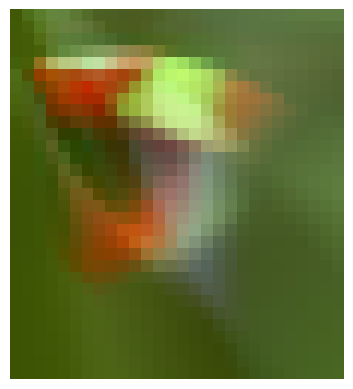

In [68]:
# IMPORTANT: 
# training code works only for 
# used_embedding = "naive"
# training and visualization code should work in both
# used_embedding = "learned"
# used_embedding = "positonal"
used_embedding = "naive"

torch.manual_seed(0)

model = train(used_embedding=used_embedding)
visualize_model_output(model)

Epoch [1/300], Loss: 128.5751470750378
Epoch [2/300], Loss: 56.93106979159166
Epoch [3/300], Loss: 51.762646793769804
Epoch [4/300], Loss: 51.36426779751404
Epoch [5/300], Loss: 49.624301189651135
Epoch [6/300], Loss: 45.67930611816969
Epoch [7/300], Loss: 44.7821054766255
Epoch [8/300], Loss: 45.730592156335504
Epoch [9/300], Loss: 46.179505871188255
Epoch [10/300], Loss: 39.47435837846747
Epoch [11/300], Loss: 38.90324219031268
Epoch [12/300], Loss: 35.17904912711288
Epoch [13/300], Loss: 32.462935381770684
Epoch [14/300], Loss: 33.04382078109249
Epoch [15/300], Loss: 32.72579857610887
Epoch [16/300], Loss: 31.215896606445312
Epoch [17/300], Loss: 29.464424660678283
Epoch [18/300], Loss: 26.982120601812266
Epoch [19/300], Loss: 26.445808691912532
Epoch [20/300], Loss: 26.890960412091374
Epoch [21/300], Loss: 25.139159945299
Epoch [22/300], Loss: 25.593892462242582
Epoch [23/300], Loss: 25.966827251944125
Epoch [24/300], Loss: 23.932512450328073
Epoch [25/300], Loss: 22.69564088039134

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7..267].


Epoch [300/300], Loss: 1.407936900442097


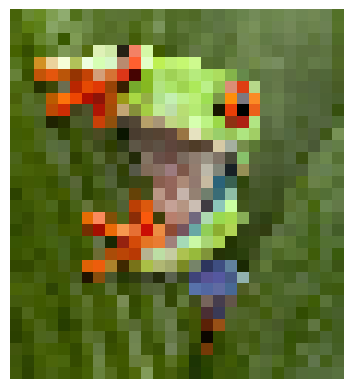

In [69]:
# IMPORTANT: 
# training code works only for 
# used_embedding = "naive"
# training and visualization code should work in both
used_embedding = "learned"
# used_embedding = "positonal"
# used_embedding = "naive"

torch.manual_seed(0)

model = train(used_embedding=used_embedding)
visualize_model_output(model)

Epoch [1/300], Loss: 114.3743889452675
Epoch [2/300], Loss: 56.121372345955145
Epoch [3/300], Loss: 51.86494621593282
Epoch [4/300], Loss: 53.95653080390895
Epoch [5/300], Loss: 53.71074082335019
Epoch [6/300], Loss: 52.47890272008659
Epoch [7/300], Loss: 48.56428112961729
Epoch [8/300], Loss: 47.28669675484231
Epoch [9/300], Loss: 46.6782721594182
Epoch [10/300], Loss: 46.17016963695051
Epoch [11/300], Loss: 44.69019637569304
Epoch [12/300], Loss: 44.3661127749676
Epoch [13/300], Loss: 41.62864372147943
Epoch [14/300], Loss: 43.08882482150732
Epoch [15/300], Loss: 44.02978072627898
Epoch [16/300], Loss: 45.38736826813166
Epoch [17/300], Loss: 43.261016775386125
Epoch [18/300], Loss: 40.81159818447131
Epoch [19/300], Loss: 38.77916647212297
Epoch [20/300], Loss: 42.472474339920254
Epoch [21/300], Loss: 39.797005719303534
Epoch [22/300], Loss: 38.30390030118178
Epoch [23/300], Loss: 37.290195166240636
Epoch [24/300], Loss: 36.57645630726616
Epoch [25/300], Loss: 34.77713582263015
Epoch 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-15..267].


Epoch [296/300], Loss: 1.5289492651064824
Epoch [297/300], Loss: 1.6617452098477272
Epoch [298/300], Loss: 2.0211732046944753
Epoch [299/300], Loss: 1.5832414473256757
Epoch [300/300], Loss: 1.9622894805697253


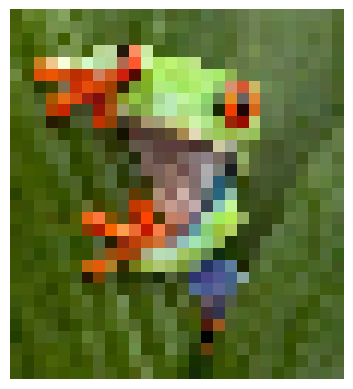

In [70]:
# IMPORTANT: 
# training code works only for 
# used_embedding = "naive"
# training and visualization code should work in both
# used_embedding = "learned"
used_embedding = "positional"
# used_embedding = "naive"

torch.manual_seed(0)

model = train(used_embedding=used_embedding)
visualize_model_output(model)